<a href="https://colab.research.google.com/github/phamtronghai/Quizz_Flutter_GetX/blob/main/docs/examples/sam3_tiled_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tiled Segmentation for Large GeoTIFF Images with SAM 3

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/segment-geospatial/blob/main/docs/examples/sam3_tiled_segmentation.ipynb)

This notebook demonstrates how to use the sliding window (tiled) approach to segment large GeoTIFF images that would otherwise exceed GPU memory limits.

## Overview

When working with large satellite or aerial imagery, loading the entire image into GPU memory for SAM 3 inference is often not feasible. The `generate_masks_tiled()` method solves this by:

1. **Dividing** the large image into smaller, overlapping tiles
2. **Processing** each tile independently with SAM 3
3. **Merging** the results back into a seamless output mask
4. **Preserving** georeferencing information from the original GeoTIFF

## Key Parameters

- **tile_size**: Size of each processing tile (default: 1024 pixels)
- **overlap**: Overlap between adjacent tiles (default: 128 pixels) - helps prevent edge artifacts
- **prompt**: Text description of objects to segment
- **min_size/max_size**: Filter objects by pixel area

## Installation

Uncomment and run the following cell to install the required packages:

In [1]:
!pip install "segment-geospatial[samgeo3]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of sam3 to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 666.5/666.5 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.2/142.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 127.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.7/276.7 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install git+https://github.com/facebookresearch/sam3.git

In [ ]:
!pip install decord

Khởi động lại phiên sau khi cài đặt

## Import Libraries

In [1]:
import os
import leafmap
from samgeo import SamGeo3, common

## Check Raster Info

Let's check the dimensions of our image to understand why tiling might be necessary.

===== RASTER INFORMATION: /content/satelliteNOIBAI19.tif =====
Driver: GTiff
Dimensions: 1678 x 1480 pixels
Number of bands: 3
Data type: uint8
Coordinate Reference System: EPSG:3857
Georeferenced Bounds: BoundingBox(left=11777646.653724661, bottom=2417330.583047228, right=11778147.59143323, top=2417772.4084915207)
Pixel Resolution: 0.298532603438433, 0.29853070560320455
NoData Value: None

----- Band Statistics -----
Band 1:
  Min: 0.00
  Max: 255.00
  Mean: 142.11
  Std Dev: 47.29
Band 2:
  Min: 0.00
  Max: 255.00
  Mean: 128.74
  Std Dev: 45.61
Band 3:
  Min: 0.00
  Max: 255.00
  Mean: 131.95
  Std Dev: 40.96


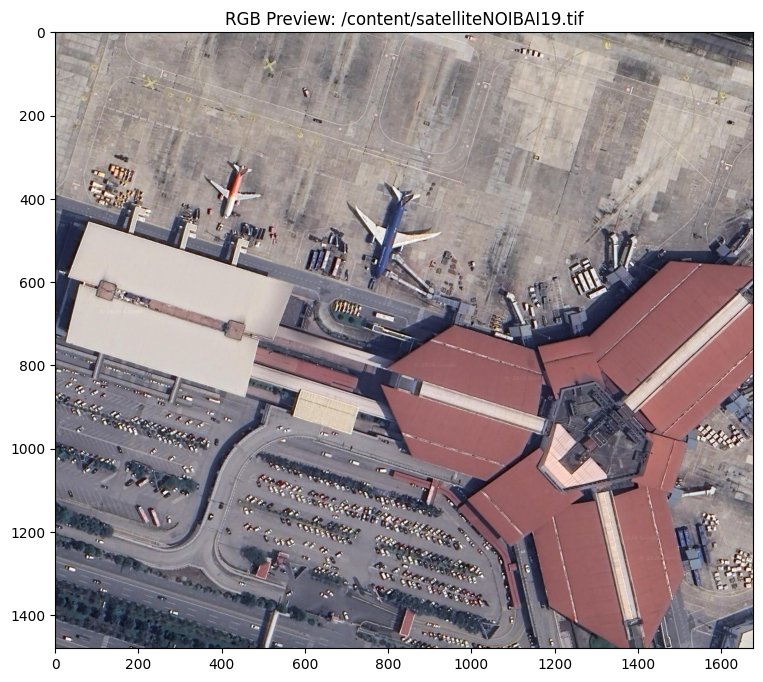

{'driver': 'GTiff',
 'width': 1678,
 'height': 1480,
 'count': 3,
 'dtype': 'uint8',
 'crs': 'EPSG:3857',
 'transform': Affine(0.298532603438433, 0.0, 11777646.653724661,
        0.0, -0.29853070560320455, 2417772.4084915207),
 'bounds': BoundingBox(left=11777646.653724661, bottom=2417330.583047228, right=11778147.59143323, top=2417772.4084915207),
 'resolution': (0.298532603438433, 0.29853070560320455),
 'nodata': None,
 'band_stats': [{'band': 1,
   'min': 0.0,
   'max': 255.0,
   'mean': 142.1139463808266,
   'std': 47.29454702163657},
  {'band': 2,
   'min': 0.0,
   'max': 255.0,
   'mean': 128.73990553425892,
   'std': 45.61380523860396},
  {'band': 3,
   'min': 0.0,
   'max': 255.0,
   'mean': 131.94811269851496,
   'std': 40.95542490240534}]}

In [4]:
image_path = "/content/satelliteNOIBAI19.tif"
common.print_raster_info(image_path)

## Initialize SamGeo3

In [4]:
!pip install git+https://github.com/facebookresearch/sam3.git

  Cloning https://github.com/facebookresearch/sam3.git to /tmp/pip-req-build-ot9w55ac
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam3.git /tmp/pip-req-build-ot9w55ac
  Resolved https://github.com/facebookresearch/sam3.git to commit f6e51f59500a87c576c2df2323ce56b9fd7a12de
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.2 MB/s eta 0:00:00
  Using cached iopath-0.1.10.tar.gz (42 kB)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 89.9 MB/s eta 0:00:00
  Created wheel for sam3: filename=sam3-0.1.0-py3-none-any.whl size=1865952 sha256=3317ea9752eaf3b6bd83176877dc81ab44782f831782dfbdaf46feb5e9ff3306
  Stored in directory: /tmp/pip-ephem-wheel-cache-eqg095wk/wheels/d0/2d/ba

In [4]:
from huggingface_hub import notebook_login
notebook_login()

In [2]:
sam = SamGeo3(backend="meta")

Using cuda device and meta backend


config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

## Run Tiled Segmentation

Now we'll use the `generate_masks_tiled()` method to process the image. This method:

1. Reads the image tile by tile
2. Processes each tile with SAM3
3. Merges overlapping regions intelligently
4. Saves the result as a georeferenced GeoTIFF

In [16]:
# Output path for the mask
output_path = "segmentation_mask_plane.tif"

# Run tiled segmentation
sam.generate_masks_tiled(
    source=image_path,
    prompt="plane",  # Change prompt based on what you want to segment
    output=output_path,
    tile_size=1024,  # Size of each tile (adjust based on GPU memory)
    overlap=128,  # Overlap between tiles
    min_size=100,  # Minimum object size in pixels
    unique=False,  # Create binary mask (0 or 1)
    dtype="int32",  # Data type for output
    verbose=True,  # Show progress
)

Processing image: 1678 x 1480 pixels
Tile size: 1024, Overlap: 128
Total tiles to process: 4 (2 x 2)


Processing tiles: 100%|██████████| 4/4 [00:08<00:00,  2.00s/it]

Saved mask to segmentation_mask_plane.tif
Total objects found: 5


'segmentation_mask_plane.tif'

## Visualize Results

In [17]:

m = leafmap.Map()
m.add_raster(image_path, layer_name="Original Image")
m.add_raster(
    output_path, nodata=0, opacity=0.8, cmap="Blues", layer_name="Segmentation Mask"
)
m

Map(center=[21.21515, 105.80265], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', …

In [ ]:
# Output path for the mask
output_path = "segmentation_mask_plane.tif"

# Run tiled segmentation
sam.generate_masks_tiled(
    source=image_path,
    prompt="plane",  # Change prompt based on what you want to segment
    output=output_path,
    tile_size=1024,  # Size of each tile (adjust based on GPU memory)
    overlap=128,  # Overlap between tiles
    min_size=100,  # Minimum object size in pixels
    unique=False,  # Create binary mask (0 or 1)
    dtype="int32",  # Data type for output
    verbose=True,  # Show progress
)

Processing image: 1678 x 1480 pixels
Tile size: 1024, Overlap: 128
Total tiles to process: 4 (2 x 2)


Processing tiles: 100%|██████████| 4/4 [00:08<00:00,  2.00s/it]

Saved mask to segmentation_mask_plane.tif
Total objects found: 5


'segmentation_mask_plane.tif'

## Convert Mask to Vector

You can convert the raster mask to vector format (GeoPackage, Shapefile, etc.) for further analysis in GIS software.

In [8]:
# Convert mask to vector
vector_path = "segmentation_mask.geojson"
common.raster_to_vector(output_path, vector_path)

## Smooth Vector

In [ ]:
smooth_vector_path = "segmentation_mask_smooth.gpkg"
gdf = common.smooth_vector(vector_path, smooth_vector_path)

In [ ]:
m.add_gdf(gdf, layer_name="Smoothed Vector", info_mode=None)
m

## Tips for Processing Large Images

1. **Tile Size**: Larger tiles capture more context but require more GPU memory. Start with 512 or 1024 and increase if you have sufficient GPU memory.

2. **Overlap**: Higher overlap (e.g., 128-256) helps prevent artifacts at tile boundaries but increases processing time. Lower overlap (e.g., 64) is faster but may have more edge effects.

3. **Memory Management**: The method automatically clears GPU memory after each tile. If you still encounter memory issues, try reducing the tile_size.

4. **Data Type**: Use `int32` for images with many objects, `int16` for up to 65535 objects, or `int8` for up to 255 objects.

5. **Filtering**: Use `min_size` and `max_size` to filter out noise (small objects) or irrelevant large regions.